<a href="https://colab.research.google.com/github/n-manato/audio-data-modeling/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition using the RAVDESS Dataset

## Objective
The goal of this notebook is to explore how speech audio can be used to classify emotions.
Using the RAVDESS dataset, I process speech recordings, visualize the audio signals, extract MFCC features, and train a simple machine learning model.
This notebook demonstrates the basic workflow of audio processing and emotion classification in Google Colab.

# Import Libraries
In this section, I import the Python libraries needed for audio processing, data handling, visualization, and machine learning.

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
In this section, I load the speech audio files from the RAVDESS dataset.
I organize the files and prepare them for audio analysis and emotion classification.

In [24]:
# Path to the dataset folder
dataset_path = "Audio_Speech_Actors_01-24"

# Emotion labels used in RAVDESS
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Collect all .wav files
audio_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

# Display basic dataset information
print("Number of audio files:", len(audio_files))
print("\nFirst 10 files with emotion labels:")

# Show file names and corresponding emotion labels
for file_path in audio_files[:10]:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]
    emotion_label = emotion_map.get(emotion_code, "unknown")
    print(f"{file_name} -> {emotion_label}")

Number of audio files: 1440

First 10 files with emotion labels:
03-01-01-01-01-01-01.wav -> neutral
03-01-01-01-01-02-01.wav -> neutral
03-01-01-01-02-01-01.wav -> neutral
03-01-01-01-02-02-01.wav -> neutral
03-01-02-01-01-01-01.wav -> calm
03-01-02-01-01-02-01.wav -> calm
03-01-02-01-02-01-01.wav -> calm
03-01-02-01-02-02-01.wav -> calm
03-01-02-02-01-01-01.wav -> calm
03-01-02-02-01-02-01.wav -> calm


# Explore Audio
In this section, I visualize sample audio files using waveforms and spectrograms.
This helps me understand the speech signals before building a model.

Sample file: 03-01-01-01-01-01-01.wav
Sampling rate: 48000
Audio shape: (158558,)


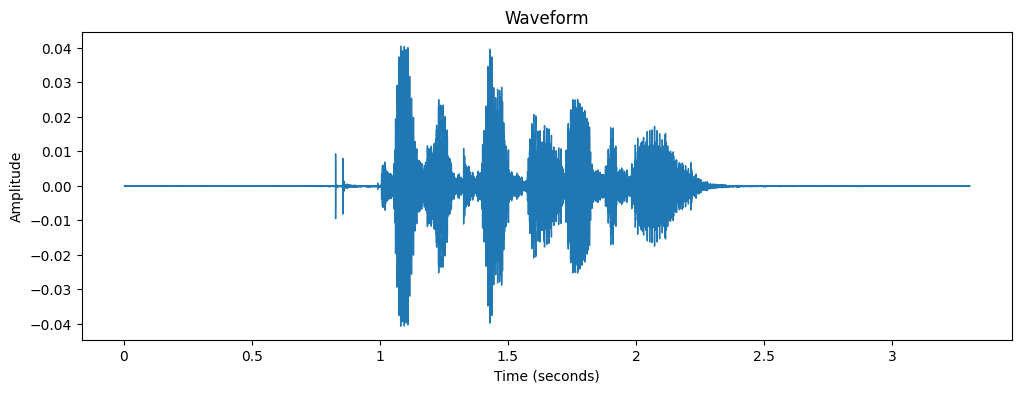

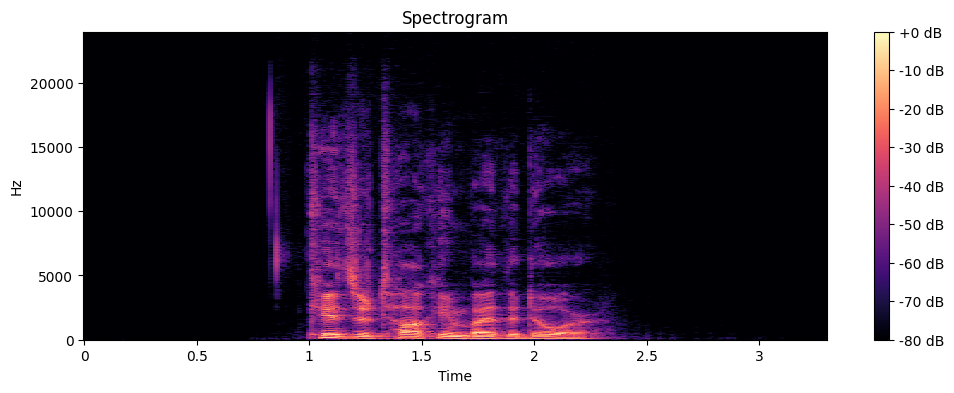

In [25]:
sample_file = audio_files[0]

y, sr = librosa.load(sample_file, sr=None)

print("Sample file:", os.path.basename(sample_file))
print("Sampling rate:", sr)
print("Audio shape:", y.shape)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

In the waveform, the signal is close to zero at the beginning and end, which suggests silence or very low background sound.
The main speech activity occurs in the middle of the recording, where the amplitude becomes much larger.

In the spectrogram, most of the strong energy appears during the same middle section.
The brighter regions are concentrated mainly in the lower frequency bands, which is typical for human speech.
These plots show that the recording contains a clear speech segment that can be used for feature extraction and emotion classification.

# Feature Extraction
In this section, I extract MFCC features from the audio files.
These features represent important information from the speech signal and will be used for model training.

MFCC shape: (13, 310)


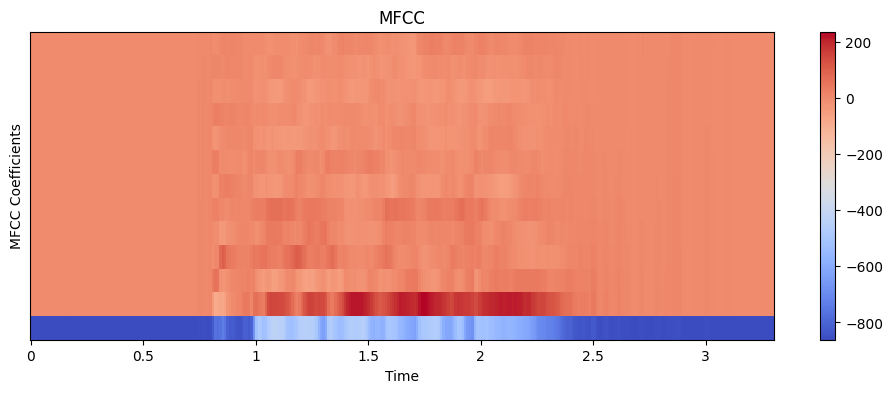

Feature matrix shape: (672, 26)
Label shape: (672,)
Sample labels: ['neutral' 'neutral' 'neutral' 'neutral' 'happy' 'happy' 'happy' 'happy'
 'happy' 'happy']


In [26]:
sample_file = audio_files[0]

y, sr = librosa.load(sample_file, sr=None)

mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("MFCC shape:", mfcc.shape)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc, x_axis="time", sr=sr)
plt.colorbar()
plt.title("MFCC")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()


selected_emotions = {"01", "03", "04", "05"}

X = []
y_labels = []

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]

    if emotion_code in selected_emotions:
        signal, sr = librosa.load(file_path, sr=None)

        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        feature_vector = np.hstack([mfcc_mean, mfcc_std])

        X.append(feature_vector)
        y_labels.append(emotion_map[emotion_code])

X = np.array(X)
y_labels = np.array(y_labels)

print("Feature matrix shape:", X.shape)
print("Label shape:", y_labels.shape)
print("Sample labels:", y_labels[:10])

The MFCC visualization shows the variation of cepstral features over time in one speech recording.
These features represent important spectral patterns in the signal and are useful for speech emotion recognition.

To build the dataset, I extract MFCCs from each audio file and compute the mean and standard deviation of each coefficient.
This allows each speech sample to be represented as a fixed-length numerical vector that can be used as input for a classification model.

# Model Training
In this section, I split the dataset into training and testing sets and train a simple machine learning model.
I use a Random Forest classifier to classify emotions from the extracted MFCC features.
The goal is to see whether the speech features can help identify emotional expression.

In [27]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Create and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Training complete.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training complete.
Training set shape: (537, 26)
Test set shape: (135, 26)


# Evaluation
In this section, I evaluate the performance of the trained model using the test dataset.
I measure the accuracy of the classifier and examine the confusion matrix and classification report.
These results help me understand how well the model can distinguish emotions from speech.

Accuracy: 0.8074074074074075

Classification Report:
              precision    recall  f1-score   support

       angry       0.83      0.92      0.88        38
       happy       0.87      0.69      0.77        39
     neutral       0.88      0.74      0.80        19
         sad       0.72      0.85      0.78        39

    accuracy                           0.81       135
   macro avg       0.82      0.80      0.81       135
weighted avg       0.82      0.81      0.81       135


Confusion Matrix:
[[35  1  0  2]
 [ 6 27  0  6]
 [ 0  0 14  5]
 [ 1  3  2 33]]
         angry  happy  neutral  sad
angry       35      1        0    2
happy        6     27        0    6
neutral      0      0       14    5
sad          1      3        2   33


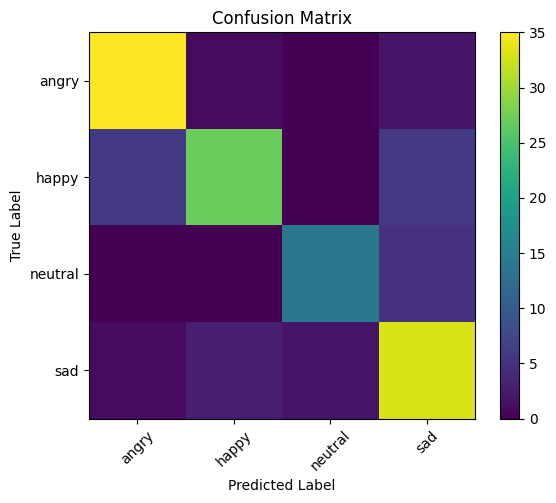

In [28]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)
print(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(model.classes_))
plt.xticks(tick_marks, model.classes_, rotation=45)
plt.yticks(tick_marks, model.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

The accuracy score shows the overall performance of the model on the test data.
The classification report provides precision, recall, and F1-score for each emotion class.
The confusion matrix shows how often each emotion was correctly classified and where the model made mistakes.

These results help us understand which emotions are easier to classify and which emotions may overlap in speech patterns.

# Conclusion
In this notebook, I explored how speech audio can be used for emotion classification.
I extracted MFCC features from the RAVDESS dataset and trained a Random Forest classifier to predict emotions from speech.

The results suggest that speech contains patterns related to emotional expression, although some emotions may be harder to separate than others.
Overall, this project helped me understand the basic workflow of audio processing and model building in Google Colab.
In the future, the model could be improved by using more features or more advanced deep learning methods.